#### Acknowledgements

This dataset was downloaded from the UCI ML Repository:

Lichman, M. (2013). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

## <strong>IMPORTS</strong>

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## <strong>MAIN</strong>

In [122]:
df = pd.read_csv('../../data/Indian Liver Patient Dataset (ILPD).csv')
columns = ['age', 'gender', 'tb', 'db', 'alkphos', 'sgpt', 'sgot', 'tp', 'alb', 'agr', 'selector']
# FEATURES
# tb - total bilirubin      db - direct bilirubin       alkphos - alkaline phosphotase
# sqpt - alamine aminotransferase       sgot - aspartate aminotransferase
# tp - total proteins       alb - albumin       agr - albumin and globulin ratio
# TARGET 
# selector - selector field used to split the data into two sets (labeled by the experts)
# 1 - patient (has liver disease)
# 2 - not patient (does not)

df.loc[-1] = df.columns
df = df.sort_index().reset_index(drop=True)
df.columns = columns
df.head()

,age,gender,tb,db,alkphos,sgpt,sgot,tp,alb,agr,selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.9,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.0,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.4,1


### PREPROCESSING

In [123]:
df['age'] = df['age'].astype("int")
df['gender'] = (df['gender']=='Female').astype("int")
df['tb'] = df['tb'].astype("float")
df['db'] = df['db'].astype("float")
df['alkphos'] = df['alkphos'].astype("int")
df['sgpt'] = df['sgpt'].astype("int")
df['sgot'] = df['sgot'].astype("int")
df['tp'] = df['tp'].astype("float")
df['alb'] = df['alb'].astype("float")
df['agr'] = df['agr'].astype("float")
df['selector'] = (df['selector']==1).astype("int")
print(df.dtypes)

print(df[df.isnull().any(axis=1)])
df['agr'] = df['agr'].fillna(df['agr'].mean())
print("___________")
df[df.isnull().any(axis=1)]

age           int64
gender        int64
tb          float64
db          float64
alkphos       int64
sgpt          int64
sgot          int64
tp          float64
alb         float64
agr         float64
selector      int64
dtype: object
     age  gender   tb   db  alkphos  sgpt  sgot   tp  alb  agr  selector
209   45       1  0.9  0.3      189    23    33  6.6  3.9  NaN         1
241   51       0  0.8  0.2      230    24    46  6.5  3.1  NaN         1
253   35       1  0.6  0.2      180    12    15  5.2  2.7  NaN         0
312   27       0  1.3  0.6      106    25    54  8.5  4.8  NaN         0
___________


,age,gender,tb,db,alkphos,sgpt,sgot,tp,alb,agr,selector


### EXPLORATORY DATA ANALYSIS

In [124]:
features = df.iloc[:, :-1]
target = df.iloc[:, -1]

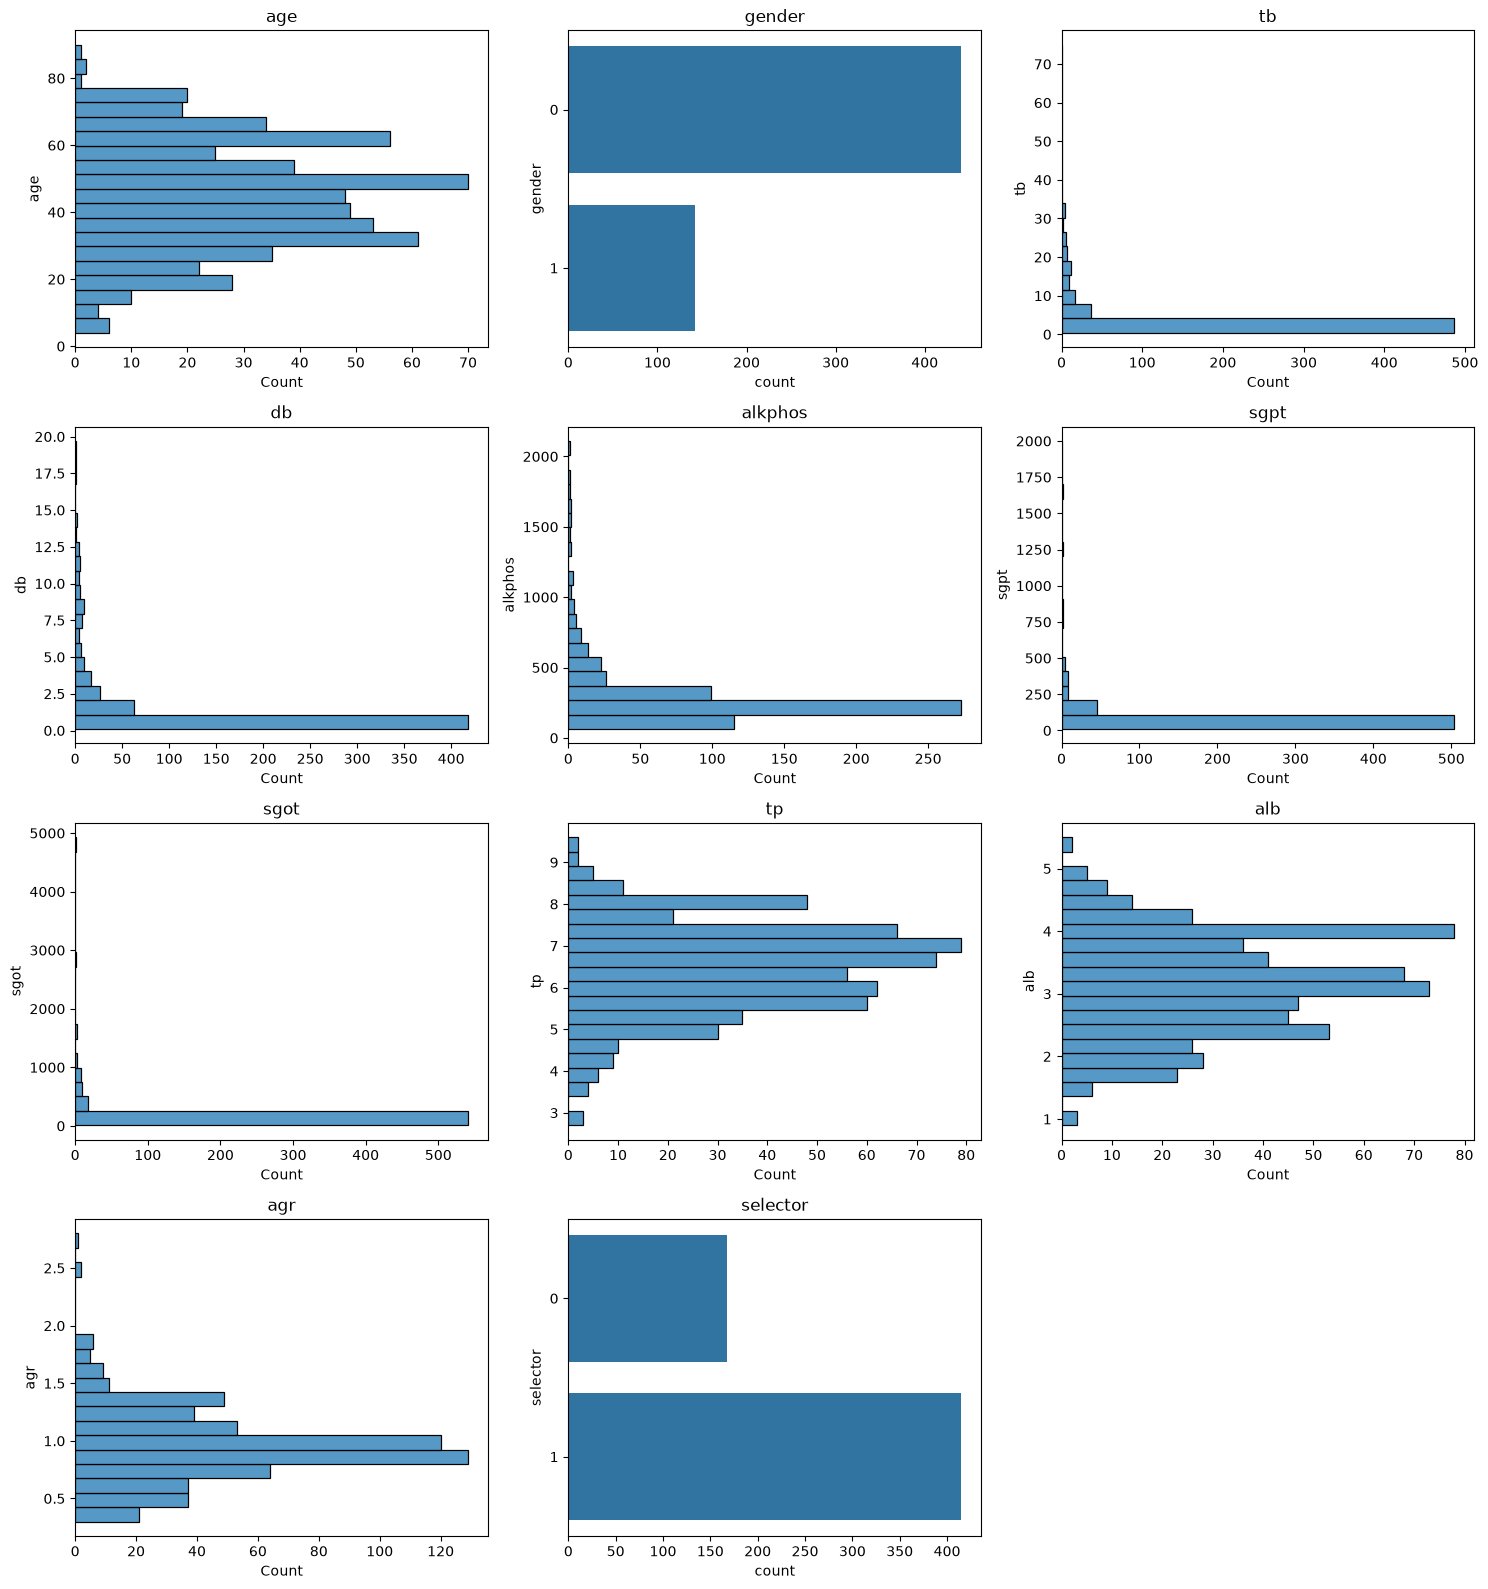

In [125]:
categorical_cols = ['gender', 'selector']  
continuous_cols = [c for c in df.columns if c not in categorical_cols]

n_cols_total = len(df.columns)
n_cols = 3
n_rows = -(-n_cols_total // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    if col in categorical_cols:
        sns.countplot(y=col, data=df, ax=axes[i])
    else:
        sns.histplot(y=col, data=df, bins=20, ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

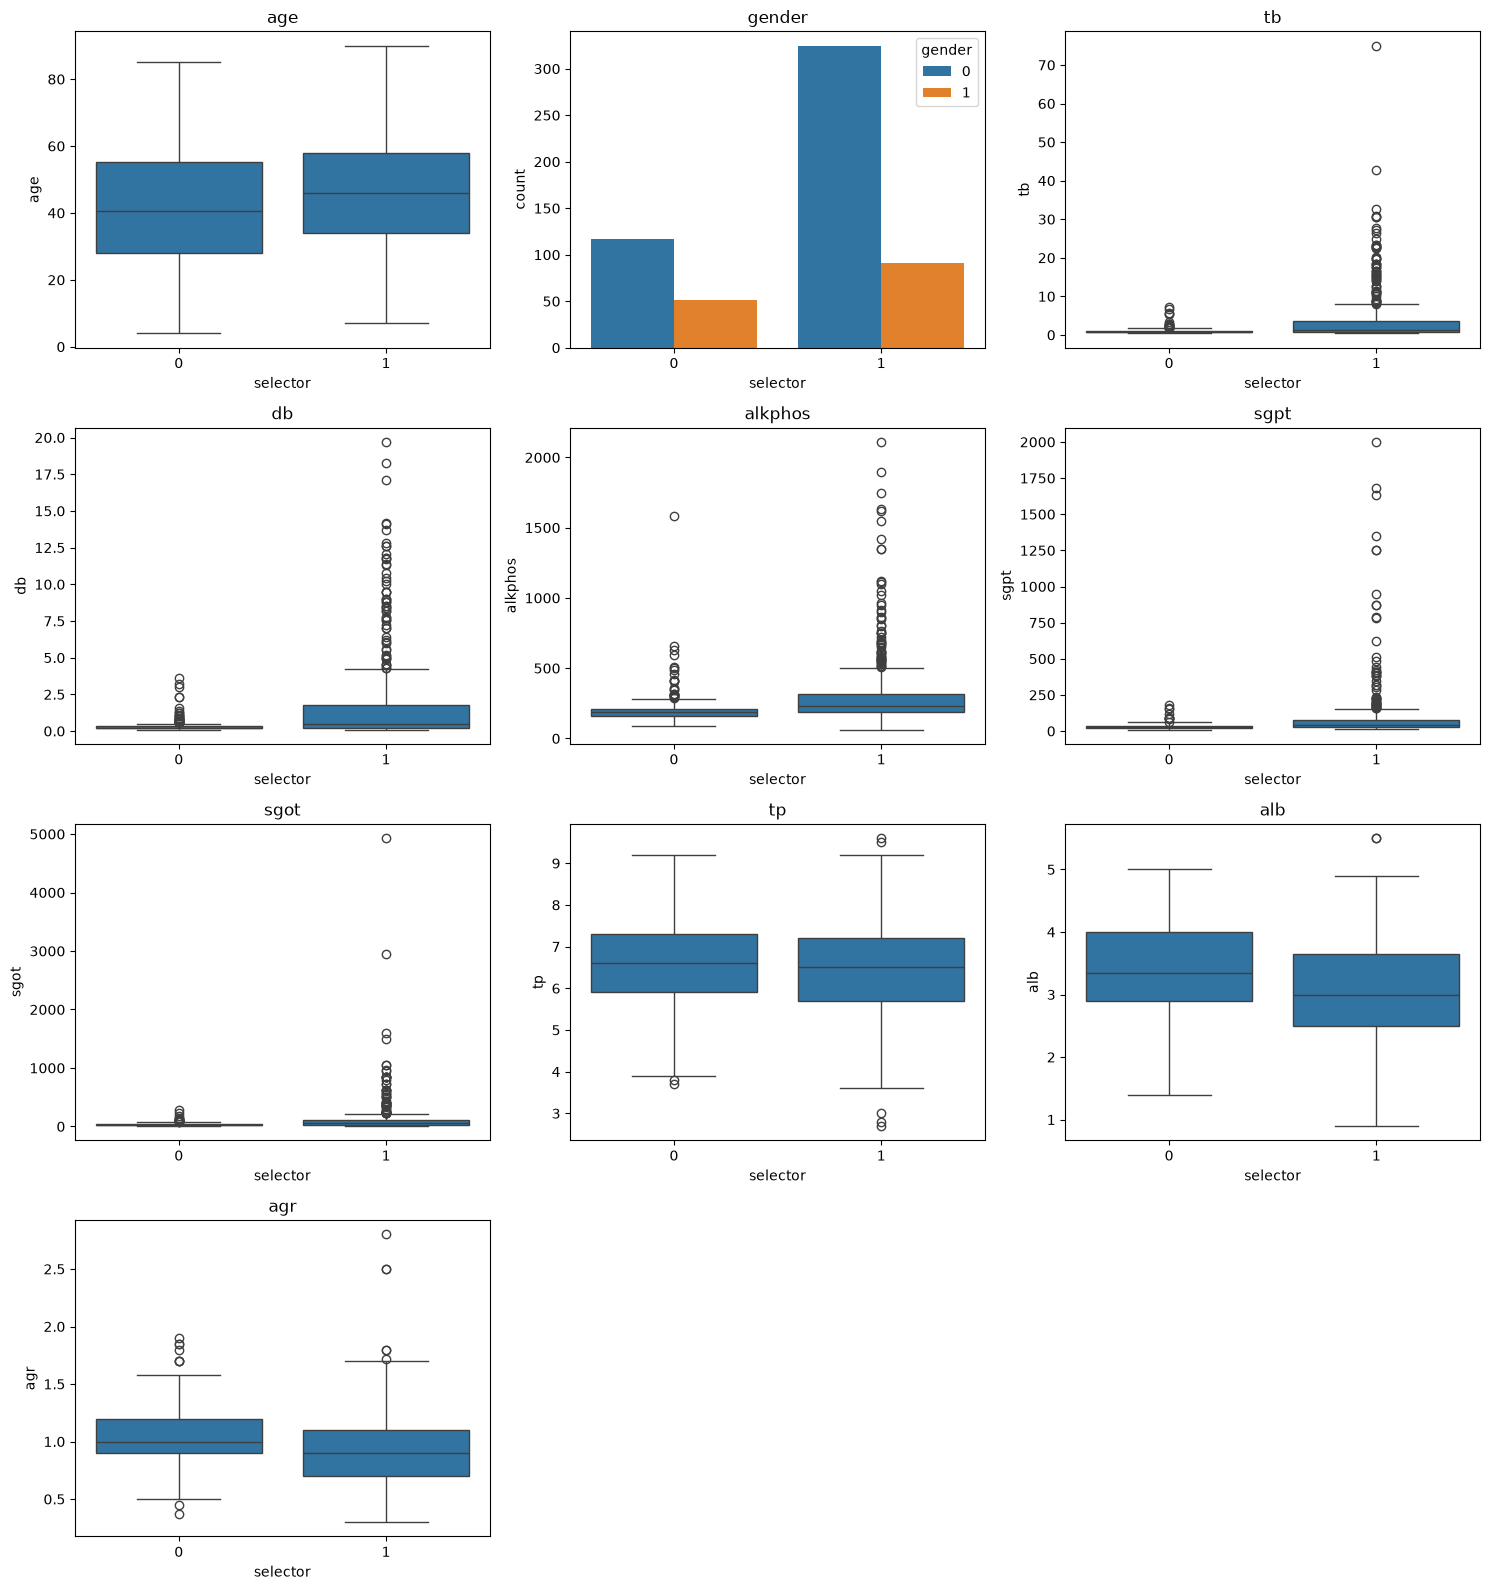

In [126]:
categorical_cols = ['gender']  
feature_cols = features.columns
n_features = len(feature_cols)

n_cols = 3
n_rows = -(-n_features // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    if col in categorical_cols:
        sns.countplot(x="selector", hue=col, data=df, ax=axes[i])
    else:
        sns.boxplot(x="selector", y=col, data=df, ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### ACTUAL TRAINING

In [127]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

xTrain, xTest, yTrain, yTest = train_test_split(scaled_features, target, random_state=42, test_size=0.25, stratify=target)

#### Logistic Regression

In [128]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression().fit(xTrain, yTrain)
pred_logreg = logreg.predict(xTest)
pred_logreg

array([1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1])

In [157]:
from sklearn.neighbors import KNeighborsClassifier

k = 22
knn_classifier = KNeighborsClassifier(n_neighbors=k)
knn_model = knn_classifier.fit(xTrain, yTrain)
pred_knn = knn_model.predict(xTest)

In [167]:
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix

print(f'Logsitic regression\nLog loss: {log_loss(yTest, pred_logreg)}')
print(f'Accuracy: {accuracy_score(yTest, pred_logreg)}')
cm_logreg = confusion_matrix(yTest, pred_logreg)
tn, fp, fn, tp = cm_logreg.ravel()
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

print(f'KNN\nLog loss: {log_loss(yTest, pred_knn)}')
print(f'Accuracy: {accuracy_score(yTest, pred_knn)}')
cm_knn = confusion_matrix(yTest, pred_knn)
tn, fp, fn, tp = cm_knn.ravel()
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

Logsitic regression
Log loss: 9.874973531264974
Accuracy: 0.726027397260274
TN: 12, FP: 30, FN: 10, TP: 94
KNN
Log loss: 8.146853163293603
Accuracy: 0.773972602739726
TN: 14, FP: 28, FN: 5, TP: 99


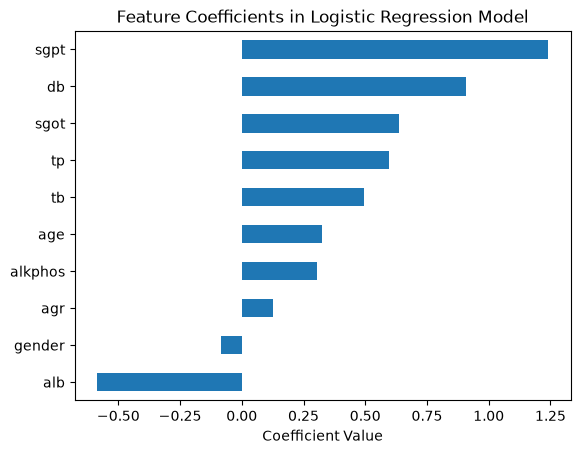

In [136]:
coefficients = pd.Series(logreg.coef_[0], index=df.columns[:-1])
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Coefficients in Logistic Regression Model")
plt.xlabel("Coefficient Value")
plt.show()